# 🖼️ Image Recognition Classifier — Colab Edition
**Advanced Level — Project 10**

Skills: TensorFlow/Keras • CNN • Training

This notebook trains a Convolutional Neural Network (CNN) to classify images using the **CIFAR-10** dataset (10 classes: airplane, car, bird, cat, deer, dog, frog, horse, ship, truck), then lets you test it on your own uploaded images.

**Before you start (Colab):** Runtime → Change runtime type → Hardware accelerator → **GPU** (speeds up training a lot).

## 1. Imports & GPU check

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU available: {bool(gpus)}", gpus)

TensorFlow version: 2.20.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load & explore the dataset
CIFAR-10 downloads automatically (~170MB) and is built into Keras — no manual dataset setup needed.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 826s 5us/step
Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)


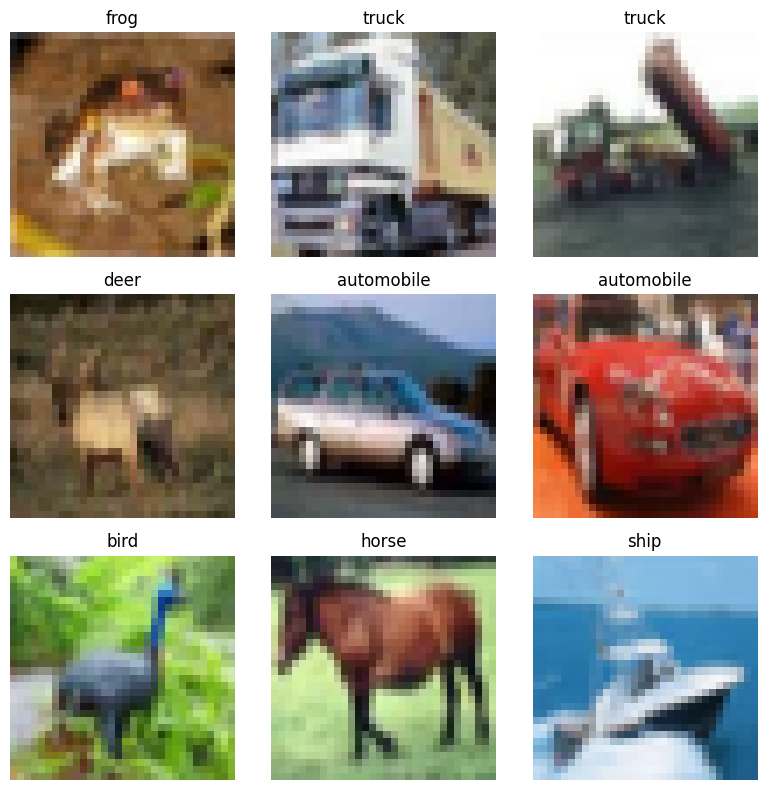

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

# Peek at a few samples
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Preprocess
Normalize pixel values to [0, 1] and one-hot encode labels.

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

# Hold out a validation split from training data
val_split = 5000
x_val, y_val = x_train[:val_split], y_train_cat[:val_split]
x_train_, y_train_ = x_train[val_split:], y_train_cat[val_split:]

print("Training on:", x_train_.shape[0], "| Validating on:", x_val.shape[0], "| Testing on:", x_test.shape[0])

Training on: 45000 | Validating on: 5000 | Testing on: 10000


## 4. Data augmentation (helps generalization, reduces overfitting)

In [5]:
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name='augmentation')

## 5. Build the CNN

In [6]:
def build_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax'),
    ])
    return model

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,818 (2.55 MB)

 Trainable params: 667,178 (2.55 MB)

 Non-trainable params: 640 (2.50 KB)

## 6. Train

In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss'),
]

history = model.fit(
    x_train_, y_train_,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.3556 - loss: 1.7894 - val_accuracy: 0.5112 - val_loss: 1.3286 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4814 - loss: 1.4447 - val_accuracy: 0.5490 - val_loss: 1.2832 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.5491 - loss: 1.2747 - val_accuracy: 0.5996 - val_loss: 1.1673 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.5897 - loss: 1.1766 - val_accuracy: 0.6666 - val_loss: 0.9548 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6171 - loss: 1.0953 - val_accuracy: 0.6930 - val_loss: 0.8951 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6430 - loss: 1.0338 - val_accuracy: 0.7282 - val_loss: 0.7967 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6640 - l

## 7. Evaluate on the test set

313/313 - 2s - 5ms/step - accuracy: 0.8211 - loss: 0.5306
Test accuracy: 0.8211


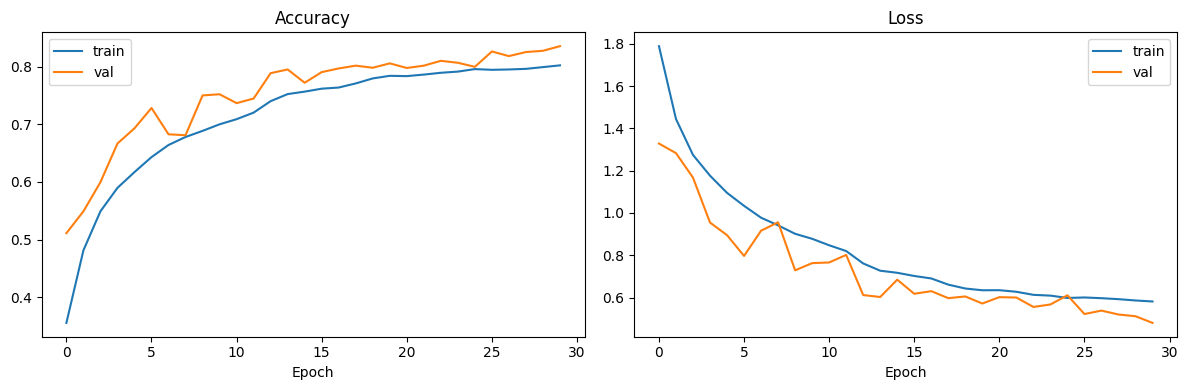

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Confusion matrix & sample predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


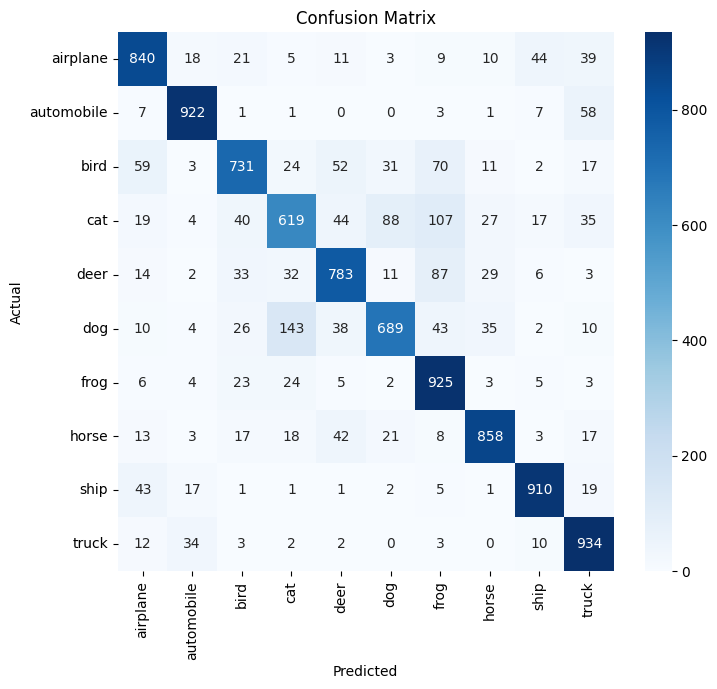

              precision    recall  f1-score   support

    airplane       0.82      0.84      0.83      1000
  automobile       0.91      0.92      0.92      1000
        bird       0.82      0.73      0.77      1000
         cat       0.71      0.62      0.66      1000
        deer       0.80      0.78      0.79      1000
         dog       0.81      0.69      0.75      1000
        frog       0.73      0.93      0.82      1000
       horse       0.88      0.86      0.87      1000
        ship       0.90      0.91      0.91      1000
       truck       0.82      0.93      0.87      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

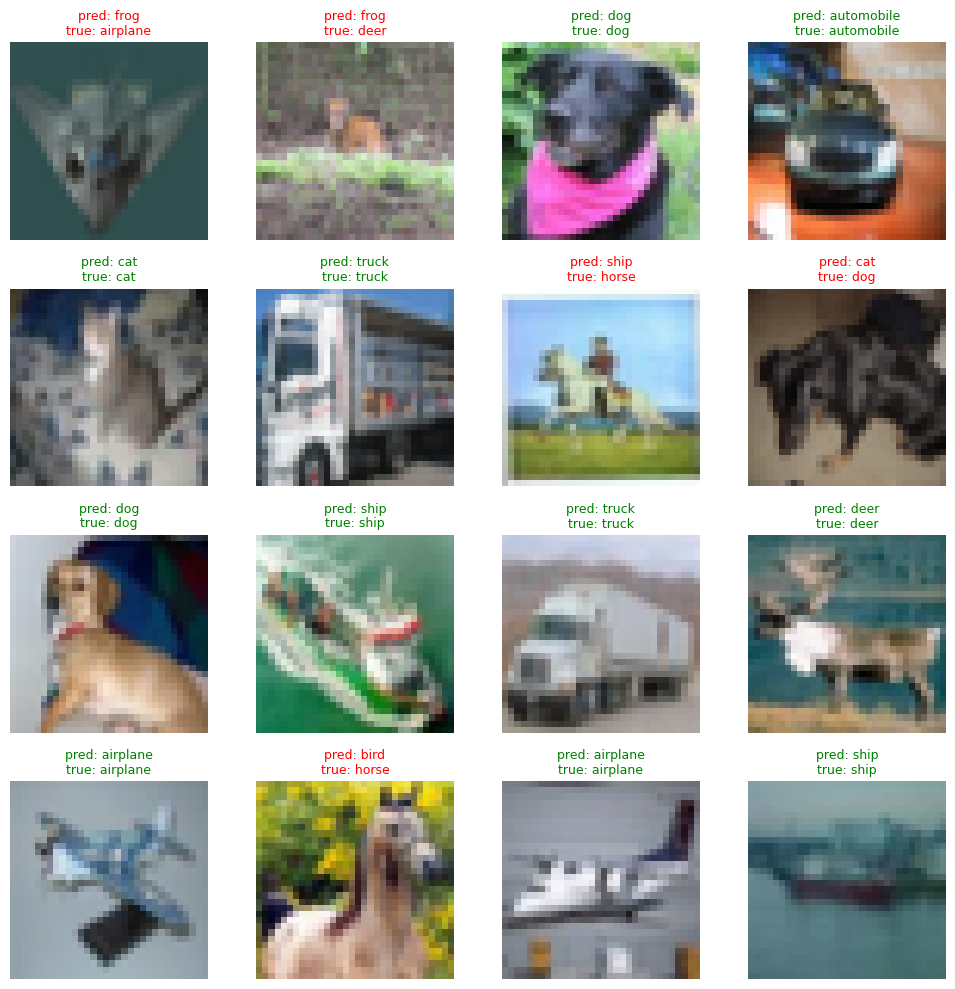

In [10]:
# Visualize a batch of predictions (green = correct, red = wrong)
plt.figure(figsize=(10, 10))
for i in range(16):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test[idx])
    pred_label = class_names[y_pred[idx]]
    true_label = class_names[y_true[idx]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"pred: {pred_label}\ntrue: {true_label}", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 9. Save the trained model

In [11]:
model.save('image_classifier.keras')
print("Saved to image_classifier.keras")

# Optional: download it to your computer
# from google.colab import files
# files.download('image_classifier.keras')

Saved to image_classifier.keras


## 10. Classify your own uploaded image

In [12]:
from google.colab import files
from PIL import Image
import io

def predict_uploaded_image():
    uploaded = files.upload()
    for fname in uploaded:
        img = Image.open(io.BytesIO(uploaded[fname])).convert('RGB')
        img_resized = img.resize((32, 32))
        arr = np.array(img_resized).astype('float32') / 255.0
        arr = np.expand_dims(arr, axis=0)

        probs = model.predict(arr)[0]
        top_idx = np.argmax(probs)

        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[top_idx]} ({probs[top_idx]*100:.1f}%)")
        plt.show()

        print("Top 3 guesses:")
        for i in np.argsort(probs)[::-1][:3]:
            print(f"  {class_names[i]:12s} {probs[i]*100:5.1f}%")

# Run this cell, then choose a file from your computer to classify:
# predict_uploaded_image()

## Notes
- **CIFAR-10 images are only 32×32px**, so custom photos get downscaled hard — accuracy on real-world photos (especially close-ups or unusual angles) will be noticeably lower than the test-set accuracy above. That's expected: the model only ever learned from small, low-res images.
- To classify **your own custom categories** instead of CIFAR-10's 10 classes, replace Section 2/3 with your own labeled image folders and use `tf.keras.utils.image_dataset_from_directory(...)`, or use **transfer learning** (e.g. `tf.keras.applications.MobileNetV2` with `include_top=False`) for much better accuracy with less data and training time.
- **PyTorch version**: the same architecture translates directly to `torch.nn.Conv2d` + `torchvision.datasets.CIFAR10` if you prefer PyTorch.